# 01 - Analyse Exploratoire des Donnees (EDA)

Ce notebook presente une EDA du dataset des offres Data Science.

Objectifs:
- verifier la qualite des donnees
- analyser la distribution des salaires
- traiter les outliers
- explorer les tendances par seniorite et competences

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Etape 1 - Chargement du dataset

On charge le fichier principal puis on affiche un apercu des premieres lignes.

In [ ]:
df = pd.read_csv('dataset_complet_final.csv')
df.head()

,job_title,company,location,post_date,seniority_level,skills,salary
0,data scientist,company_003,"Grapevine, TX . Hybrid",17 days ago,senior,"['spark', 'r', 'python', 'scala', 'machine lea...",150705.0
1,data scientist,company_005,"Fort Worth, TX . Hybrid",15 days ago,lead,"['spark', 'r', 'python', 'sql', 'machine learn...",118733.0
2,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,senior,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",127273.0
3,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,senior,"['sql', 'r', 'python']",153599.5
4,data scientist,company_009,On-site,3 days ago,NaN,[],171254.5


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(10324, 7)
job_title              str
company                str
location               str
post_date              str
seniority_level        str
skills                 str
salary             float64
dtype: object
job_title           3
company             0
location            2
post_date           0
seniority_level    60
skills             13
salary              0
dtype: int64


## Etape 2 - Nettoyage des donnees

On traite les valeurs manquantes sur les colonnes importantes (`job_title`, `seniority_level`, `location`, `skills`) puis on verifie le resultat.

In [ ]:
df['job_title'] = df['job_title'].fillna(df['job_title'].mode()[0])
df['seniority_level'] = df['seniority_level'].fillna(df['seniority_level'].mode()[0])
df = df.dropna(subset=['location'])
df = df.dropna(subset=['skills'])

In [ ]:
print(df.isnull().sum())
print(df.shape)

job_title          0
company            0
location           0
post_date          0
seniority_level    0
skills             0
salary             0
dtype: int64
(10309, 7)


## Etape 3 - Distribution des salaires et outliers

On visualise la distribution initiale, puis on applique un filtrage des valeurs extremes (quantile 99%) pour stabiliser l'analyse.

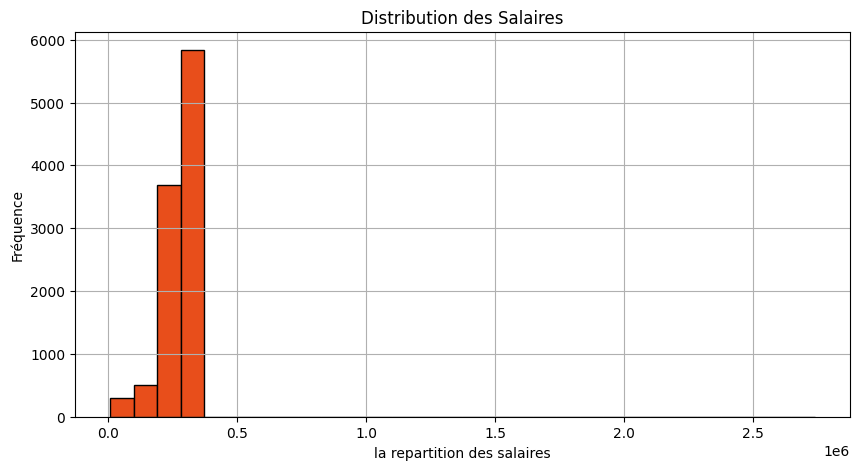

331498.36


In [ ]:
plt.figure(figsize=(10, 5))
df['salary'].hist(bins=30, color='#e84e1b', edgecolor='black')
plt.title('Distribution des Salaires')
plt.xlabel('la repartition des salaires')
plt.ylabel('Fréquence')
plt.show()

In [ ]:
df['salary'].describe() 
print(df['salary'].quantile(0.99))
df = df[df['salary'] <= 331498]
print(df.shape)

331498.36
(10197, 7)


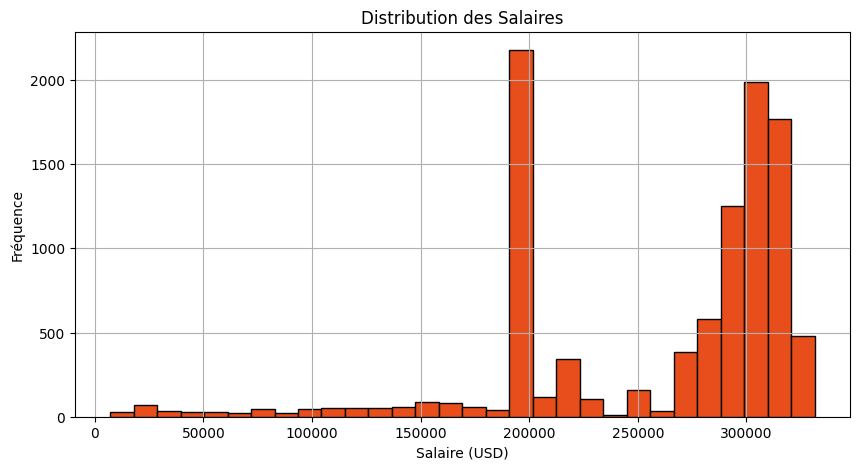

In [ ]:
plt.figure(figsize=(10, 5))
df['salary'].hist(bins=30, color='#e84e1b', edgecolor='black')
plt.title('Distribution des Salaires')
plt.xlabel('Salaire (USD)')
plt.ylabel('Fréquence')
plt.show()

## Etape 4 - Analyse metier et competences

Cette section compare les salaires par niveau de seniorite et identifie les competences les plus frequemment demandees.

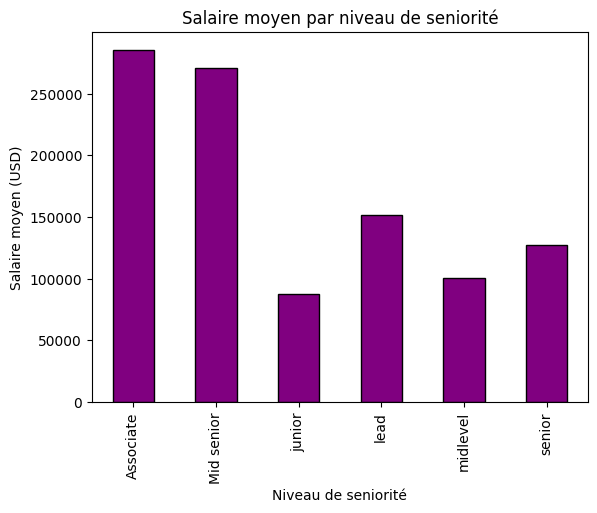

In [ ]:
df.groupby('seniority_level')['salary'].mean().plot(kind='bar', color='purple', edgecolor='black')
plt.title('Salaire moyen par niveau de seniorité')
plt.xlabel('Niveau de seniorité')
plt.ylabel('Salaire moyen (USD)')
plt.show()
top_jobs = df['job_title'].value_counts().head(10).index
df_top = df[df['job_title'].isin(top_jobs)]


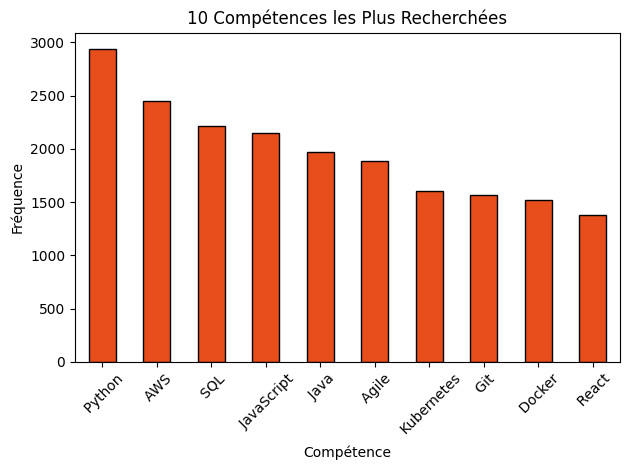

In [ ]:
skills_list = df['skills'].str.split(',')
skills_list = skills_list.explode()
top_skills = skills_list.value_counts().head(10)
top_skills.plot(kind='bar', color='#e84e1b', edgecolor='black')
plt.title('10 Compétences les Plus Recherchées')
plt.xlabel('Compétence')
plt.ylabel('Fréquence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('dataset_propre.csv', index=False)
print('✅ Dataset propre sauvegardé !')

✅ Dataset propre sauvegardé !


## Conclusion

Points cles de cette EDA:
- les donnees ont ete nettoyees et les valeurs manquantes critiques traitees
- la distribution des salaires est plus exploitable apres filtrage des outliers
- le niveau de seniorite influence fortement le salaire moyen
- certaines competences reviennent tres souvent et peuvent servir de base pour la modelisation

Suite recommandee:
- utiliser `dataset_propre.csv` pour entrainer les modeles de regression et de classification
- comparer les performances avec et sans filtrage d outliers